# Does resetting one scale contaminate the others through fusion?

## The puzzle this notebook tries to resolve

Earlier experiments on this project found two things that don't obviously fit together:

1. In **streaming inference** (`analisis_resultados.ipynb`), testing which of MDEQ's 4 multiscale branches actually need to be warm-started every frame, **scale 1 came out by far the most important** — resetting it every frame hurts mIoU roughly 5x more than resetting scale 0.
2. In **baseline, single-frame convergence** (`equilibrium_convergence.ipynb` / `convergence_population_analysis.ipynb`), measuring how fast each scale converges to its own equilibrium `z*` from a cold start, **scale 1 was never the slowest** — scale 0 was consistently the fastest, scale 3 the slowest, and scale 1 sat unremarkably in the middle.

So scale 1's outsized importance for warm-starting isn't explained by it being the "hardest" scale to solve on its own. That leaves a different hypothesis: MDEQ fuses all 4 scales together at **every** solver iteration (`fullstage`, in `mdeq_core.py`). Maybe scale 1 matters not because of its own convergence speed, but because of **how much its state affects the other 3 scales once they're fused together** — i.e., resetting scale 1 might quietly drag the other, otherwise-healthy scales away from their correct answers, in a way that resetting scale 0 doesn't.

## What we want to find

For each scale `K`, if we reset only scale `K` (keeping the other 3 already at their correct, converged values) and then run a few solver iterations, **how far do the other 3 scales end up from their own correct values**, purely as a side effect of being fused with the reset one? If scale 1 causes more of this "contamination" than scale 0 does, that's direct evidence for the fusion hypothesis. If all 4 scales cause similar contamination, the explanation must lie elsewhere.

## How we test it

We use one validation image for which we already have the true converged equilibrium `z*` saved (`z_star_cache/frame_t/` — cached equilibria of labeled evaluation frames; a sibling `z_star_cache/frame_t_minus_1/` holds equilibria of real preceding video frames, used from Section 15 onward). To isolate the fusion effect from the normal, unrelated fact that consecutive video frames differ slightly, we deliberately simplify: we pretend the "previous frame" was this exact same image, so its saved `z*` stands in for `self.prev_outs`. This is an idealization — in real streaming, the previous frame is a genuinely different image with its own natural drift — but it removes that drift entirely, so anything we measure here can only come from the reset scale and the fusion dynamics, not from the scene changing.

Concretely, for each of the 4 possible "reset scale `K`" configurations, we:

1. Set `model.prev_outs = z*` (the real, correct answer for this image).
2. Build the actual partial-init state the model already uses in streaming mode (`_build_partial_init_state(..., 'drop_scaleK_previous')`), which zeroes out scale `K` and keeps the other 3 at `z*`.
3. Run the solver for a small number of iterations (`f_thres = 1` to `8`, matching the budgets actually used in the streaming sweep) starting from that hybrid state.
4. Compare the result, scale by scale, against the known-correct `z*`.

**Sections 1-7** run this on one image. **Sections 8-11** extend it to all 500 Cityscapes validation images, using `scripts/ml_project/extract_fusion_contamination.py` (which reuses each image's already-cached `z*` rather than recomputing it) — that part of the notebook doesn't need the model or the GPU, only the files that script already wrote. **Sections 12-14** dig into per-channel behavior and verify the starting-point assumption. **Sections 15-19** drop the idealization: they redo the experiment using the *real* previous frame from the actual video sequence (not the same image pretending to be its own predecessor), as a single-image pilot. **Sections 20-24** extend that real-previous-frame version to all 500 sequences, the same way Sections 8-11 extended the idealized version.

## 1. Setup: GPU, paths, imports

`CUDA_VISIBLE_DEVICES` must be set **before** `import torch`. GPU 2 is free right now (the earlier sweep sessions have all finished), so we use it here.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Same chdir workaround used in every other notebook in this project: lib/models/mdeq.py
# uses paths relative to the process's cwd, which only lines up with MDEQ-Vision/ if we
# chdir there first (this notebook lives one level deeper, in results/ml_project/).
MDEQ_VISION_ROOT = Path("../..").resolve()
assert (MDEQ_VISION_ROOT / "lib").is_dir(), f"expected lib/ at {MDEQ_VISION_ROOT / 'lib'}"
os.chdir(MDEQ_VISION_ROOT)
sys.path.insert(0, "lib")

import models
import datasets
from config import config

print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())
print("cwd:", os.getcwd())

torch 2.4.1 | cuda available: True
cwd: /home/sjansasoy/StreamDEQ-2/streamdeq-code/Cityscapes/MDEQ-Vision


## 2. Load config, build the model, load pretrained weights

Same config and loading code used in `equilibrium_convergence.ipynb`. `DEQ.MODE` in this YAML is `baseline`, but that doesn't matter here — we never call `model.forward()` (which is what reads `DEQ.MODE`), only `model._forward()` directly, so we control the solver's behavior ourselves through the arguments we pass it.

In [2]:
CFG_PATH = "experiments/cityscapes/seg_mdeq_XL_sf_27i_gpu0.yaml"

config.defrost()
config.merge_from_file(CFG_PATH)
config.freeze()

model = eval("models." + config.MODEL.NAME + ".get_seg_net")(config)

pretrained_dict = torch.load(config.TEST.MODEL_FILE, map_location="cpu", weights_only=False)
model_dict = model.state_dict()
pretrained_dict = {k[6:]: v for k, v in pretrained_dict.items() if k[6:] in model_dict.keys()}
print(f"loaded {len(pretrained_dict)} / {len(model_dict)} tensors from checkpoint")
model_dict.update(pretrained_dict)
model.load_state_dict(model_dict)

model = model.cuda().eval()
print("model ready on", next(model.parameters()).device)

loaded 131 / 131 tensors from checkpoint


model ready on cuda:0


## 3. Load the same validation image, and its already-saved z*

We reuse the exact image and cached equilibrium from `equilibrium_convergence.ipynb` (`frankfurt_000000_000294_leftImg8bit`) instead of recomputing anything — we already verified this z\* is correct and reproducible, so there's no reason to redo that work.

In [3]:
test_size = (config.TEST.IMAGE_SIZE[1], config.TEST.IMAGE_SIZE[0])
test_dataset = eval("datasets." + config.DATASET.DATASET)(
    root=config.DATASET.ROOT,
    list_path=config.DATASET.TEST_SET,
    num_samples=None,
    num_classes=config.DATASET.NUM_CLASSES,
    multi_scale=False,
    flip=False,
    ignore_label=config.TRAIN.IGNORE_LABEL,
    base_size=config.TEST.BASE_SIZE,
    crop_size=test_size,
    downsample_rate=1,
)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

image, label, size, name = next(iter(testloader))
image_gpu = image.cuda()
print("image:", name[0], image.shape)

Z_STAR_PATH = Path("results/ml_project/z_star_cache/frame_t") / f"{name[0]}_f{config.DEQ.F_THRES}_z_star.pt"
z_star_cpu = torch.load(Z_STAR_PATH, map_location="cpu", weights_only=False)
z_star = [z.cuda() for z in z_star_cpu]

SCALE_CHANNELS = [z.shape[1] for z in z_star]
print("z* loaded from", Z_STAR_PATH)
for i, z in enumerate(z_star):
    print(f"  scale {i}: shape={tuple(z.shape)}  std={z.std().item():.4f}")

image: frankfurt_000000_000294_leftImg8bit torch.Size([1, 3, 1024, 2048])
z* loaded from results/ml_project/z_star_cache/frame_t/frankfurt_000000_000294_leftImg8bit_f27_z_star.pt
  scale 0: shape=(1, 88, 256, 512)  std=0.0682
  scale 1: shape=(1, 176, 128, 256)  std=0.0496
  scale 2: shape=(1, 352, 64, 128)  std=0.0449
  scale 3: shape=(1, 704, 32, 64)  std=0.0357


## 4. The core experiment

`_build_partial_init_state(prev_outs, partial_init_mode)` is the model's own method (`lib/models/mdeq.py`) — the exact same code the real streaming sweep uses, not a reimplementation. Passing it `z_star` as `prev_outs` and e.g. `'drop_scale1_previous'` gives back a 4-scale state where scale 1 is zeroed out and scales 0, 2, 3 are already at their correct, converged values.

For each of the 4 "reset scale K" configurations, and for `f_thres = 1` to `8` (the same iteration budgets used in the real streaming sweep), we run the solver starting from that hybrid state and compare the result to `z*`, scale by scale. We track both the raw MSE and a version normalized by each scale's own natural variance (`z_star_var`) — raw MSE alone would make scale 0 look more "contaminated" than scale 3 just because scale 0 naturally has more variance, not because anything special happened to it.

In [4]:
DROP_MODES = ["drop_scale0_previous", "drop_scale1_previous", "drop_scale2_previous", "drop_scale3_previous"]
F_THRES_VALUES = list(range(1, 9))  # 1..8, matching the iteration budgets used in the real streaming sweep

z_star_var = [z.var().item() for z in z_star]  # each scale's own natural variance, for normalizing across scales
print("z* variance per scale:", [f"{v:.5f}" for v in z_star_var])

mse_raw = {mode: [[] for _ in range(4)] for mode in DROP_MODES}   # mse_raw[mode][scale] -> list over f_thres
mse_norm = {mode: [[] for _ in range(4)] for mode in DROP_MODES}  # same, divided by that scale's own variance

with torch.no_grad():
    for mode in DROP_MODES:
        init_state = model._build_partial_init_state(z_star, mode)
        for ft in F_THRES_VALUES:
            y, _, _ = model._forward(
                [image_gpu, init_state], train_step=-1, compute_jac_loss=False, f_thres=ft,
            )
            for i in range(4):
                mse = (y[i] - z_star[i]).pow(2).mean().item()
                mse_raw[mode][i].append(mse)
                mse_norm[mode][i].append(mse / z_star_var[i])

print(f"\ndone: {len(DROP_MODES)} configurations x {len(F_THRES_VALUES)} iteration budgets = "
      f"{len(DROP_MODES) * len(F_THRES_VALUES)} forward passes")

z* variance per scale: ['0.00465', '0.00246', '0.00202', '0.00127']



done: 4 configurations x 8 iteration budgets = 32 forward passes


## 5. Per-scale error, one panel per configuration

One panel per "reset scale K" configuration, showing all 4 scales' MSE against `z*` as `f_thres` increases. The reset scale is drawn dashed so it stands out from the 3 scales that started already-correct. If fusion contamination is real, the solid (kept) lines should sit visibly above zero — worse than perfect — especially in the panel where scale 1 is the one reset.

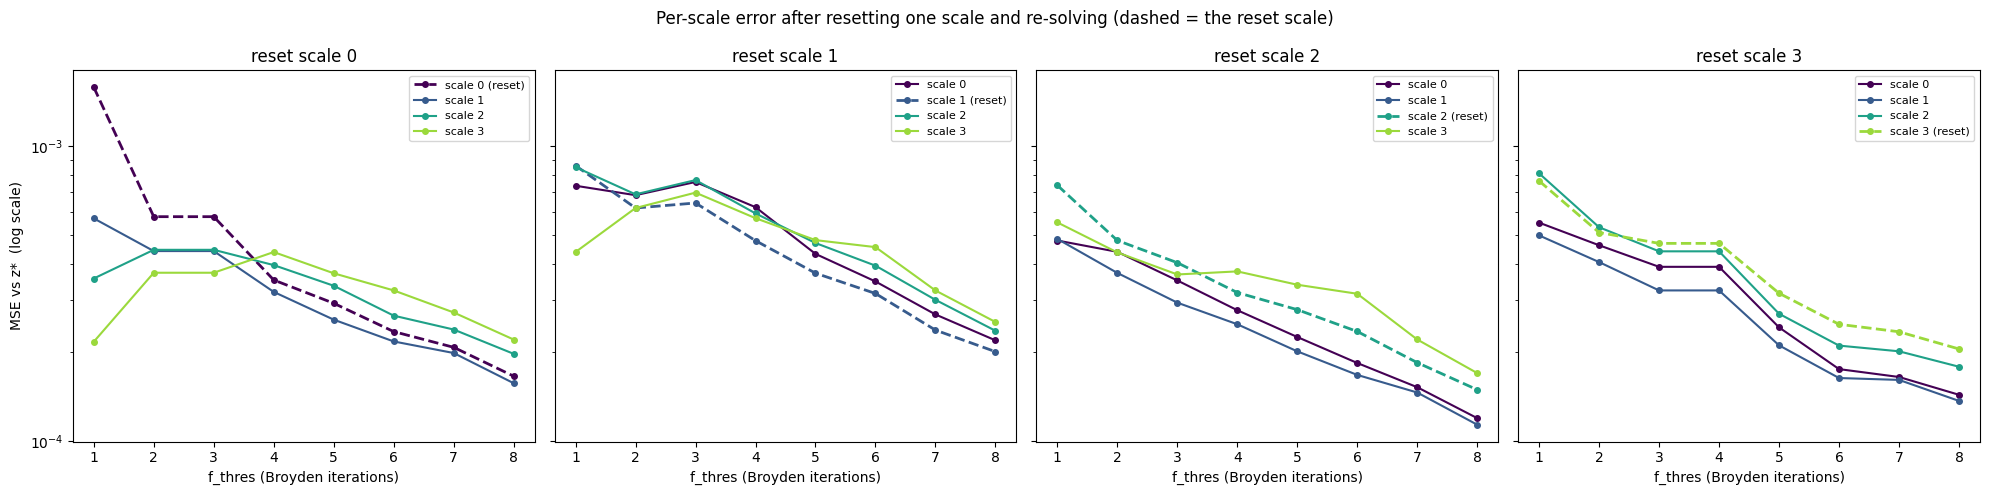

In [5]:
colors = plt.cm.viridis(np.linspace(0, 0.85, 4))

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for mode_idx, mode in enumerate(DROP_MODES):
    ax = axes[mode_idx]
    dropped_scale = mode_idx  # drop_scale0_previous resets scale 0, drop_scale1_previous resets scale 1, etc.
    for i in range(4):
        is_dropped = (i == dropped_scale)
        ax.plot(
            F_THRES_VALUES, mse_raw[mode][i], color=colors[i],
            linestyle="--" if is_dropped else "-", lw=2 if is_dropped else 1.5,
            marker="o", ms=4, label=f"scale {i}" + (" (reset)" if is_dropped else ""),
        )
    ax.set_yscale("log")
    ax.set_xlabel("f_thres (Broyden iterations)")
    ax.set_title(f"reset scale {dropped_scale}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("MSE vs z*  (log scale)")
fig.suptitle("Per-scale error after resetting one scale and re-solving (dashed = the reset scale)")
plt.tight_layout()
plt.show()

## 6. Contamination score: how much do the healthy scales suffer?

This is the comparison the whole notebook is built around. For each "reset scale K" configuration, we average the **normalized** MSE of the 3 scales that were *not* reset — that number is the "contamination score" for resetting scale K. If the fusion hypothesis is right, resetting scale 1 should produce a clearly higher score than resetting scale 0.

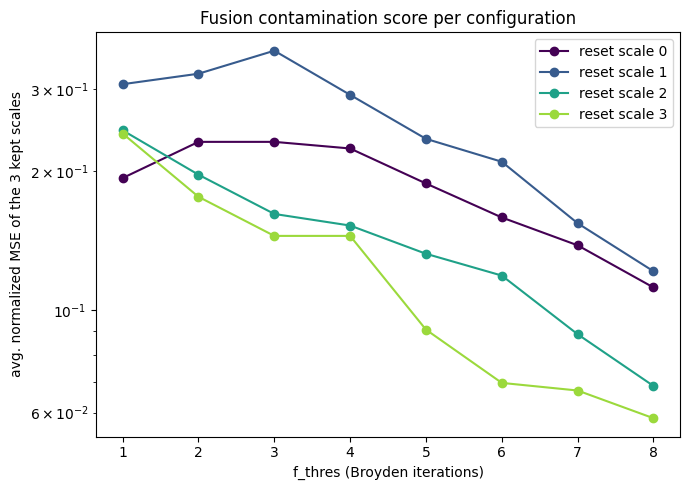

Contamination score at f_thres=4:
  reset scale 0: 2.2348e-01
  reset scale 1: 2.9186e-01
  reset scale 2: 1.5224e-01
  reset scale 3: 1.4460e-01

For reference, how far the reset scale itself still is from z* at the same f_thres (does it recover?):
  reset scale 0: 7.5547e-02
  reset scale 1: 1.9434e-01
  reset scale 2: 1.5819e-01
  reset scale 3: 3.6831e-01


In [6]:
contamination_score = {}
for mode_idx, mode in enumerate(DROP_MODES):
    kept_scales = [i for i in range(4) if i != mode_idx]
    contamination_score[mode] = np.mean([mse_norm[mode][i] for i in kept_scales], axis=0)  # (len(F_THRES_VALUES),)

fig, ax = plt.subplots(figsize=(7, 5))
for mode_idx, mode in enumerate(DROP_MODES):
    ax.plot(F_THRES_VALUES, contamination_score[mode], color=colors[mode_idx], marker="o",
            label=f"reset scale {mode_idx}")
ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("avg. normalized MSE of the 3 kept scales")
ax.set_title("Fusion contamination score per configuration")
ax.legend()
plt.tight_layout()
plt.show()

REFERENCE_FT = 4  # a representative, realistic mid-budget from the streaming sweep
ft_idx = F_THRES_VALUES.index(REFERENCE_FT)
print(f"Contamination score at f_thres={REFERENCE_FT}:")
for mode_idx, mode in enumerate(DROP_MODES):
    print(f"  reset scale {mode_idx}: {contamination_score[mode][ft_idx]:.4e}")

print("\nFor reference, how far the reset scale itself still is from z* at the same f_thres (does it recover?):")
for mode_idx, mode in enumerate(DROP_MODES):
    print(f"  reset scale {mode_idx}: {mse_norm[mode][mode_idx][ft_idx]:.4e}")

## 7. Conclusion (single image)

The contamination score for **reset scale 1** is the highest of the four across the *entire* range of realistic budgets (`f_thres = 1` to `8`), not just at one arbitrary point — at `f_thres=4` it's 0.29, versus 0.22 for scale 0, and 0.15 for scales 2 and 3. Resetting scale 1 disturbs the 3 otherwise-correct scales noticeably more than resetting any other scale does, for this one image.

That's a real, sustained signal in favor of the fusion hypothesis: scale 1 doesn't just fail to help the others when it's reset — it actively drags them further from their correct answers than resetting any other scale would. This lines up with the original puzzle: scale 1 isn't special in how fast it converges on its own (the second printed check above, "how far the reset scale itself still is from z\*", actually shows scale 1 in the *middle* of the pack — scale 0 recovers fastest, scale 3 slowest, matching the baseline convergence findings), but it does appear to be special in how much its absence disrupts everything else once fusion happens.

This is one image, and the setup is deliberately idealized (a perfect "previous frame" that's really the same image). Sections 8-11 below check whether this holds across all 500 validation images; checking it against real consecutive video frames instead of this same-image stand-in remains open for later.

## 8. Extending to all 500 validation images

The single image above is a promising signal, but one image isn't enough to trust on its own. `scripts/ml_project/extract_fusion_contamination.py` repeats the exact same experiment (all 4 `drop_scaleK_previous` modes, `f_thres=1..8`) for every validation image, reusing each image's already-cached `z*` instead of recomputing anything, and saves the resulting per-channel MSE to `results/ml_project/fusion_contamination_all_images.pt`.

This section, like Sections 1-7, does **not** need the model or the GPU — it only reads that file, plus each image's cached `z*` (just to get its per-scale variance, for the same normalization used in Section 6).

In [7]:
FUSION_RESULTS_PATH = Path("results/ml_project/fusion_contamination_all_images.pt")

fusion_results = torch.load(FUSION_RESULTS_PATH, map_location="cpu", weights_only=False)
fusion_image_names = fusion_results["image_names"]
fusion_mse_stack = torch.stack(fusion_results["mse"])  # (num_images, 4 modes, 8 f_thres, 1320 channels)

boundaries = np.cumsum([0] + SCALE_CHANNELS)  # channel boundaries per scale, e.g. [0, 88, 264, 616, 1320]

print(f"{len(fusion_image_names)} images loaded from {FUSION_RESULTS_PATH.name}")
print("shape (images, modes, f_thres, channels):", tuple(fusion_mse_stack.shape))

500 images loaded from fusion_contamination_all_images.pt
shape (images, modes, f_thres, channels): (500, 4, 8, 1320)


## 9. Contamination score per image

Same idea as Section 6, computed separately for each of the 500 images: normalize each scale's MSE by that image's own `z*` variance for that scale (each image has a somewhat different variance, so this has to be per-image, not a single fixed number), then average the 3 *kept* scales to get one contamination score per image, per configuration, per `f_thres`.

In [8]:
Z_STAR_DIR = Path("results/ml_project/z_star_cache/frame_t")

# Each image's own per-scale z* variance (needed to normalize, same reasoning as Section 6).
z_star_var_per_image = np.zeros((len(fusion_image_names), 4))
for img_idx, img_name in enumerate(fusion_image_names):
    z_star_cpu_i = torch.load(Z_STAR_DIR / f"{img_name}_f27_z_star.pt", map_location="cpu", weights_only=False)
    for i in range(4):
        z_star_var_per_image[img_idx, i] = z_star_cpu_i[i].var().item()

# contamination_per_image[image, mode, f_thres] = avg. normalized MSE of the 3 kept scales
contamination_per_image = np.zeros((len(fusion_image_names), len(DROP_MODES), len(F_THRES_VALUES)))
for mode_idx in range(len(DROP_MODES)):
    kept_scales = [i for i in range(4) if i != mode_idx]
    for i in kept_scales:
        sl = slice(boundaries[i], boundaries[i + 1])
        scale_mse = fusion_mse_stack[:, mode_idx, :, sl].mean(dim=2).numpy()  # (images, f_thres)
        contamination_per_image[:, mode_idx, :] += scale_mse / z_star_var_per_image[:, i:i + 1]
contamination_per_image /= 3

print("done -- contamination_per_image shape (images, modes, f_thres):", contamination_per_image.shape)

done -- contamination_per_image shape (images, modes, f_thres): (500, 4, 8)


## 10. Contamination score across all 500 images

Same chart as Section 6, but now the median across all 500 images, with a 10th-90th percentile band showing how much this varies from image to image.

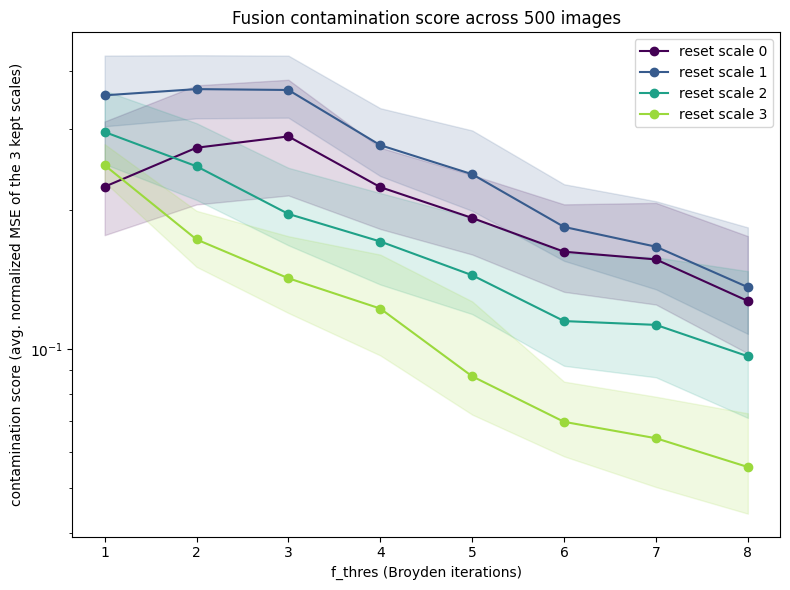

Contamination score at f_thres=4, across all 500 images:
  reset scale 0: median=2.2407e-01  mean=2.2749e-01
  reset scale 1: median=2.7618e-01  mean=2.8151e-01
  reset scale 2: median=1.7090e-01  mean=1.7626e-01
  reset scale 3: median=1.2235e-01  mean=1.2508e-01


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for mode_idx in range(len(DROP_MODES)):
    data = contamination_per_image[:, mode_idx, :]  # (images, f_thres)
    median = np.median(data, axis=0)
    p10, p90 = np.percentile(data, [10, 90], axis=0)
    ax.plot(F_THRES_VALUES, median, color=colors[mode_idx], marker="o", label=f"reset scale {mode_idx}")
    ax.fill_between(F_THRES_VALUES, p10, p90, color=colors[mode_idx], alpha=0.15)

ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("contamination score (avg. normalized MSE of the 3 kept scales)")
ax.set_title(f"Fusion contamination score across {len(fusion_image_names)} images")
ax.legend()
plt.tight_layout()
plt.show()

REFERENCE_FT = 4
ft_idx = F_THRES_VALUES.index(REFERENCE_FT)
print(f"Contamination score at f_thres={REFERENCE_FT}, across all {len(fusion_image_names)} images:")
for mode_idx in range(len(DROP_MODES)):
    vals = contamination_per_image[:, mode_idx, ft_idx]
    print(f"  reset scale {mode_idx}: median={np.median(vals):.4e}  mean={vals.mean():.4e}")

## 11. Overall conclusion

The single-image result holds up across the full validation set. Median contamination score at `f_thres=4`: **0.224 (reset scale 0), 0.276 (reset scale 1), 0.171 (reset scale 2), 0.122 (reset scale 3)** — resetting scale 1 is the worst option for the other 3 scales, consistently, not just in the one image we started with. The ordering is visible across essentially the whole `f_thres=1..8` range, not just at one arbitrary budget, and the percentile bands show real image-to-image variability without changing which scale comes out on top.

This is now solid, population-level evidence for the fusion hypothesis: scale 1's outsized importance for warm-starting doesn't come from being the hardest scale to solve on its own (the baseline convergence notebooks ruled that out), but resetting it does measurably disturb the other 3 scales more than resetting any other scale — a real side effect of fusing all 4 scales together at every solver step. The natural next step, if it's worth pursuing further, is checking whether this same pattern holds with real consecutive video frames instead of the idealized same-image stand-in used here.

## 12. Checking the starting-point assumption

Your intuition is correct in principle: at the true starting point (before the solver takes even one step), the 3 kept scales are placed *exactly* at `z*` (MSE = 0, by construction — `_build_partial_init_state` copies them verbatim), while the reset scale starts at zero, so its distance from `z*` at that instant is just `mean(z*[reset_scale]^2)` (the MSE between zero and `z*` is exactly the mean of `z*` squared).

But that instant — call it `f_thres=0` — **isn't in the data we extracted**. `F_THRES_VALUES` starts at 1, and `f_thres=1` already means "run the solver for 1 iteration," i.e., one full fusion step has already happened by the time we take our first measurement. So the plots below won't show the kept scales sitting exactly at 0 — by `f_thres=1`, they've already picked up some contamination. That's not a contradiction of your assumption; it's exactly the effect this whole notebook is trying to measure, just showing up from the very first data point we have.

We don't need to re-run anything to check the true `f_thres=0` point, though — it's fully determined by `z*` alone, so we can compute it directly from the cached files.

In [10]:
# Each channel's MSE, averaged over the 500 images -- the base data for all the per-channel plots below.
channel_avg_per_mode = fusion_mse_stack.mean(dim=0).numpy()  # (4 modes, 8 f_thres, 1320 channels)

# The 3 kept scales are exact copies of z*, so their MSE at the true f_thres=0 is exactly 0 --
# nothing to compute, it's true by construction. The only thing worth computing is how far the
# *reset* scale starts from z*: MSE(0, z*) = mean(z*^2), per channel, per image.
mse_from_zero_per_image = np.zeros((len(fusion_image_names), sum(SCALE_CHANNELS)))
for img_idx, img_name in enumerate(fusion_image_names):
    z_star_cpu_i = torch.load(Z_STAR_DIR / f"{img_name}_f27_z_star.pt", map_location="cpu", weights_only=False)
    per_channel = torch.cat([z.pow(2).mean(dim=(0, 2, 3)) for z in z_star_cpu_i])
    mse_from_zero_per_image[img_idx] = per_channel.numpy()

mse_from_zero_avg = mse_from_zero_per_image.mean(axis=0)  # (1320,), averaged over the 500 images

print("Confirming the assumption:")
print("  kept scales at the true f_thres=0: MSE = 0.0 exactly (they ARE z*, nothing to measure)")
print()
print("  reset scale's own distance from z* at the true f_thres=0 (mean(z*^2) per scale), vs. what")
print("  we actually measure one iteration later, at f_thres=1 (already averaged over images):")
for scale_idx in range(4):
    sl = slice(boundaries[scale_idx], boundaries[scale_idx + 1])
    at_zero = mse_from_zero_avg[sl].mean()
    at_f1 = channel_avg_per_mode[scale_idx, 0, sl].mean()  # mode_idx == scale_idx: this scale is the one reset
    print(f"  scale {scale_idx}: f_thres=0 -> {at_zero:.4e}   |   f_thres=1 -> {at_f1:.4e}   "
          f"(already recovered {100 * (1 - at_f1 / at_zero):.1f}% in one iteration)")

Confirming the assumption:
  kept scales at the true f_thres=0: MSE = 0.0 exactly (they ARE z*, nothing to measure)

  reset scale's own distance from z* at the true f_thres=0 (mean(z*^2) per scale), vs. what
  we actually measure one iteration later, at f_thres=1 (already averaged over images):
  scale 0: f_thres=0 -> 4.6642e-03   |   f_thres=1 -> 1.6022e-03   (already recovered 65.6% in one iteration)
  scale 1: f_thres=0 -> 2.6253e-03   |   f_thres=1 -> 9.6583e-04   (already recovered 63.2% in one iteration)
  scale 2: f_thres=0 -> 1.8648e-03   |   f_thres=1 -> 7.4271e-04   (already recovered 60.2% in one iteration)
  scale 3: f_thres=0 -> 1.2441e-03   |   f_thres=1 -> 7.7031e-04   (already recovered 38.1% in one iteration)


## 13. Every individual channel, one figure per "reset scale K" configuration

For each of the 4 configurations, one figure with 4 panels (one per scale), each showing every one of that scale's channels (88, 176, 352 or 704 lines) as a thin, semi-transparent curve — the average over all 500 images, `f_thres=1..8`. The panel matching the reset scale is outlined in red so it's easy to tell apart from the 3 kept-scale panels next to it.

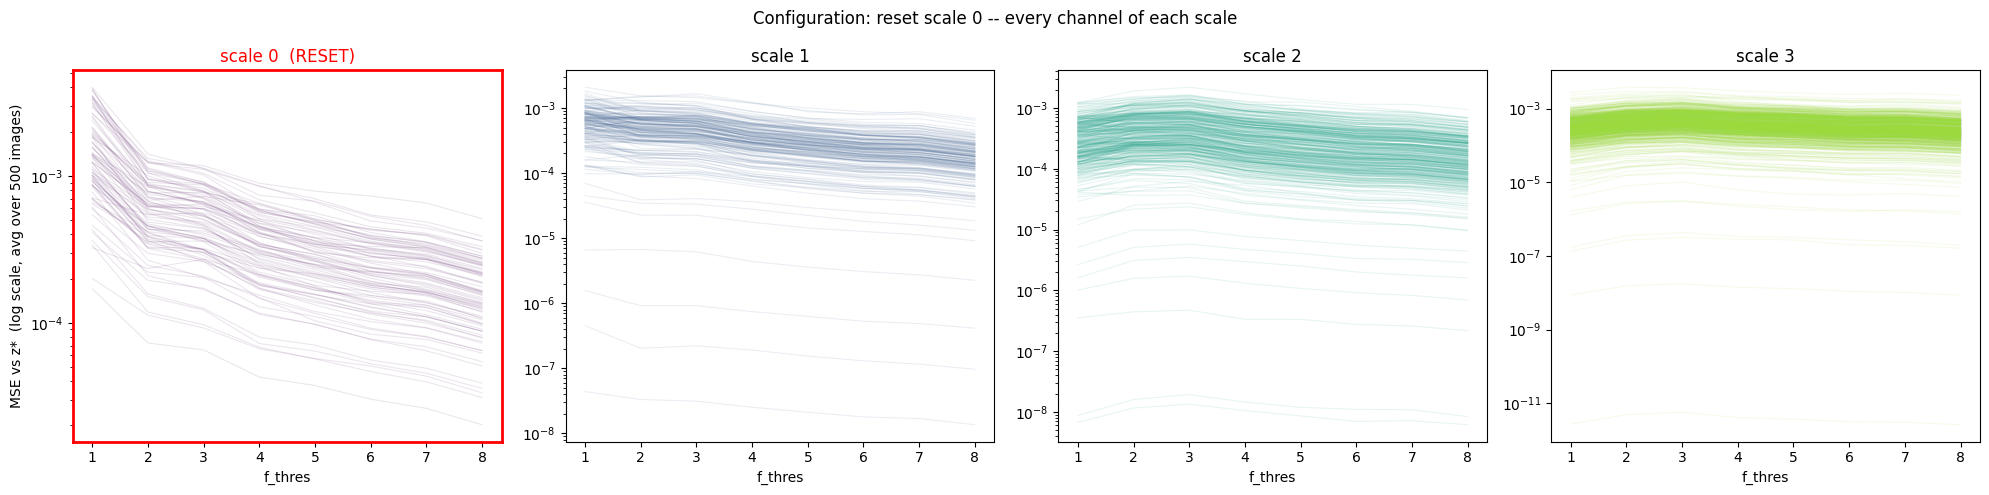

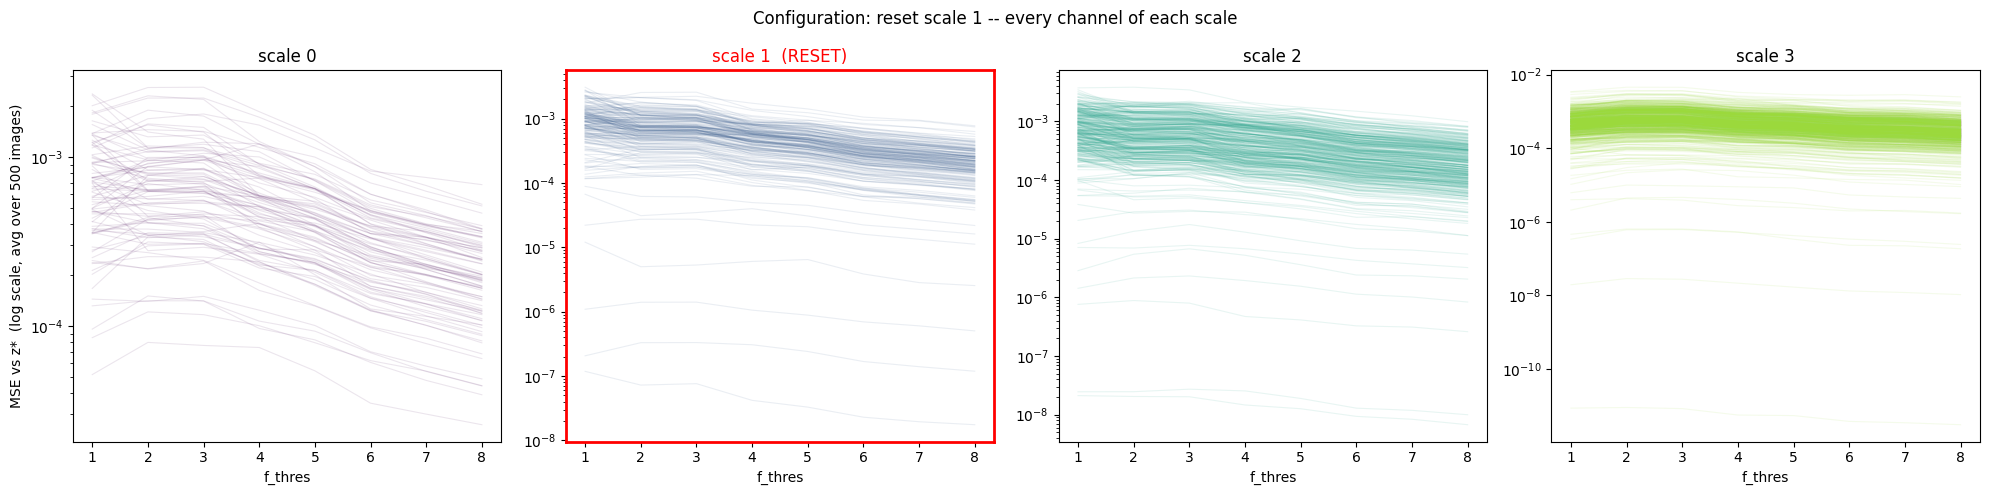

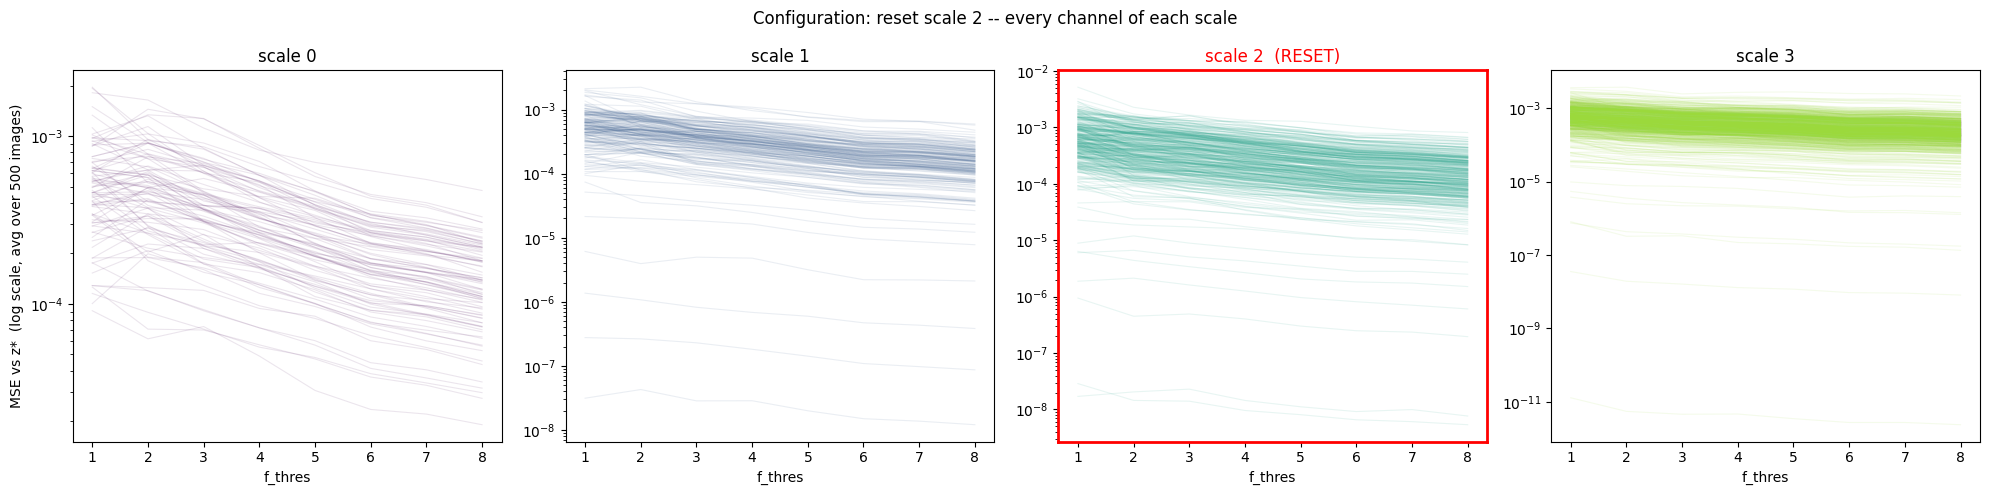

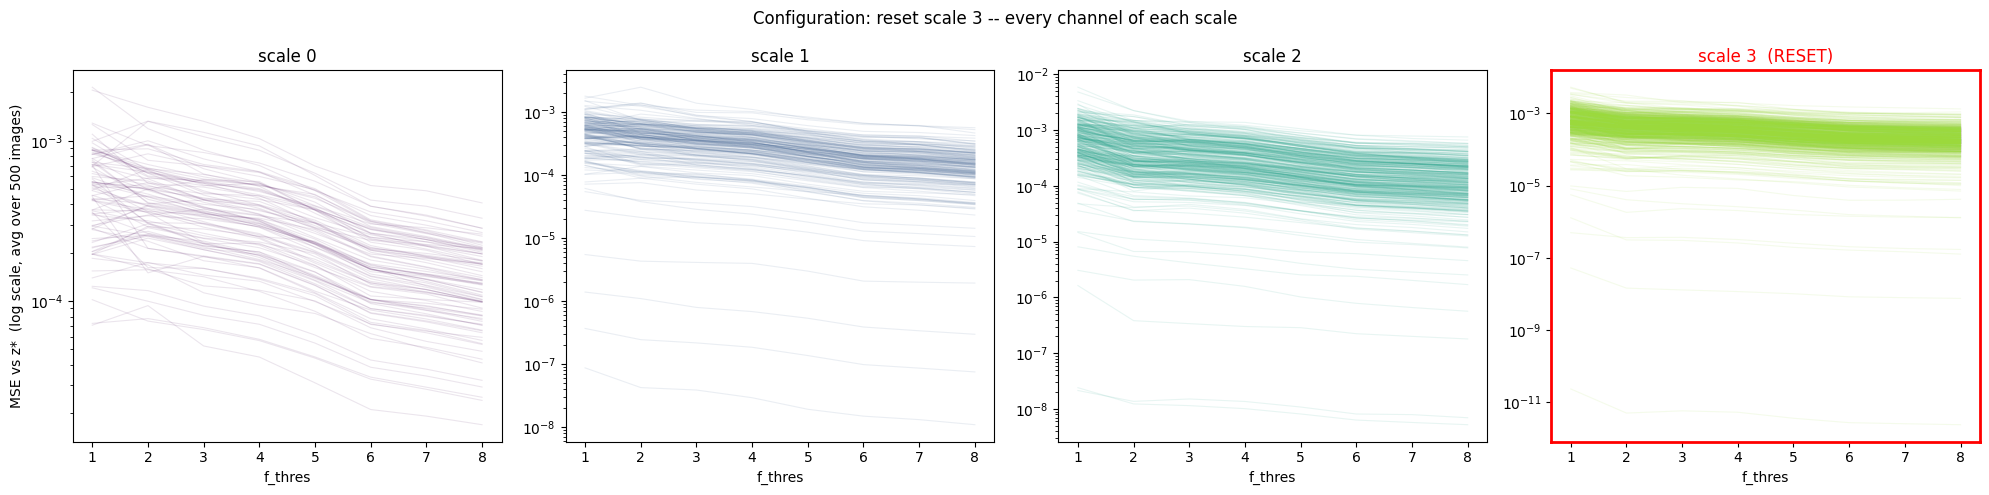

In [11]:
def plot_fusion_channels(mode_idx):
    reset_scale = mode_idx  # drop_scale0_previous resets scale 0, drop_scale1_previous resets scale 1, etc.
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
    for scale_idx, ax in enumerate(axes):
        sl = slice(boundaries[scale_idx], boundaries[scale_idx + 1])
        data = channel_avg_per_mode[mode_idx, :, sl]  # (8 f_thres, n_channels_in_this_scale)
        for c in range(data.shape[1]):
            ax.plot(F_THRES_VALUES, data[:, c], color=colors[scale_idx], alpha=0.1, lw=0.8)
        ax.set_yscale("log")
        ax.set_xlabel("f_thres")
        is_reset = (scale_idx == reset_scale)
        ax.set_title(f"scale {scale_idx}" + ("  (RESET)" if is_reset else ""),
                     color="red" if is_reset else "black")
        if is_reset:
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(2)

    axes[0].set_ylabel("MSE vs z*  (log scale, avg over 500 images)")
    fig.suptitle(f"Configuration: reset scale {reset_scale} -- every channel of each scale")
    plt.tight_layout()
    plt.show()


for mode_idx in range(4):
    plot_fusion_channels(mode_idx)

## 14. Conclusion (per-channel view)

Two patterns show up consistently across all 4 configurations, beyond what the single contamination-score number in Sections 6/10 could show:

- **Scale 3 barely moves in any of the 4 figures, whether it's the reset scale or a kept one.** When scale 3 itself is reset (last figure), its own recovery curve is almost flat across the whole `f_thres=1..8` range — 8 iterations clearly isn't enough for it to make real progress on its own (consistent with it needing a median of ~21 iterations to reach even 10% of its own initial error, found in `convergence_population_analysis.ipynb`). And whenever scale 3 is a *kept* scale (the other 3 panels), its band is also essentially flat, regardless of which other scale was reset — it doesn't seem to react much either way within this short a budget.
- **Scale 0 is the most reactive kept scale.** In the "reset scale 1" and "reset scale 2" figures, scale 0's panel shows a clear bump — its error briefly *rises* around `f_thres=2-3` before decaying — much more pronounced than scale 1 or scale 2 show in the other configurations. Scale 0 is both the fastest scale to recover when it's the one reset (Section 12: 65.6% of its own error gone after just one iteration, the highest of the four) and the most visibly disturbed kept scale when someone else is reset — it reacts quickly in both directions.

Put together with Sections 6 and 10: scale 1 causes the most *aggregate* contamination, but this per-channel view adds a nuance — it's scale 0 that *shows* the disturbance most clearly and quickly, while scale 3 is largely inert on this timescale regardless of what happens elsewhere. That's consistent with the population-level convergence story (`convergence_population_analysis.ipynb`): scale 0 is the fastest, most reactive scale in general; scale 3 is the slowest, and that sluggishness shows up here too, independent of whether it's the scale being reset.

## 15. Pilot: warm-starting from a real previous frame

Sections 1-14 all used an idealized stand-in for the previous frame: the same image's own `z*`, pretending it was a different frame. That removed frame-to-frame content drift entirely, which was useful for isolating the fusion mechanism cleanly, but it's not what real streaming inference ever actually has available.

`frankfurt_000000_000294` (the image used throughout this notebook) is, in reality, the *last* frame of a real video snippet — Cityscapes ships the unlabeled frames that precede every labeled validation image, under `leftImg8bit_sequence/`. The frame immediately before it, `frankfurt_000000_000293`, is a real, genuinely different image.

This section repeats the same two questions as before, but replacing the idealized `z*` with the *real* equilibrium of frame 293, `z*_{t-1}`, computed the same way we computed `z*` for every other image in this project (baseline mode, `f_thres=27`):

1. **Convergence with a real warm start, no scale reset** (Section 17) — the natural control/baseline: how far is the model from `z*_t` after `f_thres=1..8` iterations, starting from the real previous frame's equilibrium, without touching anything?
2. **Effect of resetting one scale** (Section 18) — the same `drop_scaleK` experiment as Sections 4-6, now starting from `z*_{t-1}` instead of the idealized same-image stand-in.

This is still a single-image pilot (same practice as the rest of the notebook): confirm the pipeline and the numbers make sense here before extending to all 500 sequences. It is *not* yet the fully paper-faithful setup either — real StreamDEQ never has access to a clean 27-iteration `z*_{t-1}`, only whatever partially-converged state survives a chain of small-iteration warm starts (see the discussion that led here); that fully faithful version is a separate, later step.

## 16. Loading the real previous frame and computing its equilibrium `z*_{t-1}`

`frankfurt_000000_000293_leftImg8bit.png` lives under `data/cityscapes/leftImg8bit_sequence/val/frankfurt/` — a real frame Cityscapes provides but never labels. We load and preprocess it exactly like any other frame (`test_dataset.input_transform`, the same BGR→RGB + normalize step every image in this project goes through), then compute its own baseline equilibrium with `f_thres=27`, identically to how every `z*` in `z_star_cache/` was produced. We cache the result under `z_star_cache/frame_t_minus_1/` (a sibling of `frame_t/`, which holds the labeled frames' equilibria) so it's always unambiguous which frame a given cached `z*` belongs to, and so it can be reused later (e.g. by a population-level extraction script) without recomputing it every time this notebook runs.

In [12]:
import cv2

PREV_FRAME_NAME = "frankfurt_000000_000293_leftImg8bit"
PREV_FRAME_PATH = Path("data/cityscapes/leftImg8bit_sequence/val/frankfurt") / f"{PREV_FRAME_NAME}.png"
assert PREV_FRAME_PATH.exists(), f"missing real previous frame at {PREV_FRAME_PATH}"

prev_image_bgr = cv2.imread(str(PREV_FRAME_PATH), cv2.IMREAD_COLOR)
prev_image = test_dataset.input_transform(prev_image_bgr)  # BGR->RGB, /255, -mean, /std
prev_image = prev_image.transpose((2, 0, 1))
prev_image_gpu = torch.from_numpy(prev_image.copy()).unsqueeze(0).float().cuda()
print("previous frame:", PREV_FRAME_NAME, prev_image_gpu.shape)

Z_STAR_PREV_DIR = Path("results/ml_project/z_star_cache/frame_t_minus_1")
Z_STAR_PREV_DIR.mkdir(parents=True, exist_ok=True)
Z_STAR_PREV_PATH = Z_STAR_PREV_DIR / f"{PREV_FRAME_NAME}_f{config.DEQ.F_THRES}_z_star.pt"
if Z_STAR_PREV_PATH.exists():
    z_star_prev_cpu = torch.load(Z_STAR_PREV_PATH, map_location="cpu", weights_only=False)
    print("loaded cached z*_(t-1) from", Z_STAR_PREV_PATH)
else:
    with torch.no_grad():
        z_star_prev_gpu, _, _ = model._forward(
            [prev_image_gpu, None], train_step=-1, compute_jac_loss=False, f_thres=config.DEQ.F_THRES,
        )
    z_star_prev_cpu = [z.cpu() for z in z_star_prev_gpu]
    torch.save(z_star_prev_cpu, Z_STAR_PREV_PATH)
    print("computed and cached z*_(t-1) to", Z_STAR_PREV_PATH)

z_star_prev = [z.cuda() for z in z_star_prev_cpu]
print("\nz*_(t-1) (real previous frame) vs. z*_t (current frame, from Section 3):")
for i, (zp, zt) in enumerate(zip(z_star_prev, z_star)):
    print(f"  scale {i}: shape={tuple(zp.shape)}  std(z*_prev)={zp.std().item():.4f}  std(z*_t)={zt.std().item():.4f}")

previous frame: frankfurt_000000_000293_leftImg8bit torch.Size([1, 3, 1024, 2048])
loaded cached z*_(t-1) from results/ml_project/z_star_cache/frame_t_minus_1/frankfurt_000000_000293_leftImg8bit_f27_z_star.pt

z*_(t-1) (real previous frame) vs. z*_t (current frame, from Section 3):
  scale 0: shape=(1, 88, 256, 512)  std(z*_prev)=0.0682  std(z*_t)=0.0682
  scale 1: shape=(1, 176, 128, 256)  std(z*_prev)=0.0496  std(z*_t)=0.0496
  scale 2: shape=(1, 352, 64, 128)  std(z*_prev)=0.0452  std(z*_t)=0.0449
  scale 3: shape=(1, 704, 32, 64)  std(z*_prev)=0.0354  std(z*_t)=0.0357


## 17. Convergence with a real warm start (no scale reset)

Before looking at what happens when we reset a scale, we need the control case: what does the model output look like if we warm-start from the real `z*_{t-1}` and don't touch anything? All 4 scales start from the real previous frame's equilibrium (not zero, and not the idealized same-image `z*`), and we just let the solver run `f_thres=1..8` iterations, comparing against `z*_t`.

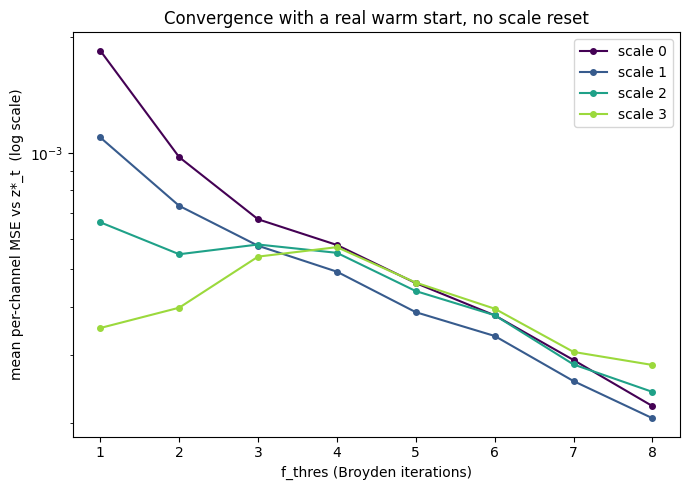

Real warm-start (no reset), mean per-channel MSE vs z*_t:
  scale 0: f_thres=1 -> 1.8405e-03   f_thres=8 -> 2.2089e-04
  scale 1: f_thres=1 -> 1.0967e-03   f_thres=8 -> 2.0546e-04
  scale 2: f_thres=1 -> 6.6115e-04   f_thres=8 -> 2.4040e-04
  scale 3: f_thres=1 -> 3.5195e-04   f_thres=8 -> 2.8228e-04


In [13]:
mse_per_scale_realwarm = [[] for _ in range(4)]

with torch.no_grad():
    for ft in F_THRES_VALUES:
        y, _, _ = model._forward(
            [image_gpu, z_star_prev], train_step=-1, compute_jac_loss=False, f_thres=ft,
        )
        for i in range(4):
            per_channel_mse = (y[i] - z_star[i]).pow(2).mean(dim=(0, 2, 3)).cpu()
            mse_per_scale_realwarm[i].append(per_channel_mse)

mse_per_scale_realwarm = [torch.stack(scale_list) for scale_list in mse_per_scale_realwarm]  # (8, C_i) per scale

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(4):
    avg_mse = mse_per_scale_realwarm[i].mean(dim=1)  # average over channels, keep per-f_thres
    ax.plot(F_THRES_VALUES, avg_mse.numpy(), marker="o", ms=4, color=colors[i], label=f"scale {i}")
ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("mean per-channel MSE vs z*_t  (log scale)")
ax.set_title("Convergence with a real warm start, no scale reset")
ax.legend()
plt.tight_layout()
plt.show()

print("Real warm-start (no reset), mean per-channel MSE vs z*_t:")
for i in range(4):
    print(f"  scale {i}: f_thres=1 -> {mse_per_scale_realwarm[i][0].mean().item():.4e}   "
          f"f_thres=8 -> {mse_per_scale_realwarm[i][-1].mean().item():.4e}")

## 18. Effect of resetting one scale, using the real previous frame

Same experiment as Sections 4-6, with one change: `_build_partial_init_state` is now called on `z_star_prev` (the real equilibrium of frame 293) instead of the idealized same-image `z*`. Everything else — the 4 `drop_scaleK_previous` modes, the `f_thres=1..8` sweep, the normalization by `z_star_var` (still each scale's own variance at `z*_t`, so the results stay directly comparable to Sections 6-7) — is identical.

done: 4 configurations x 8 iteration budgets, using the real previous frame (frankfurt_000000_000293_leftImg8bit)


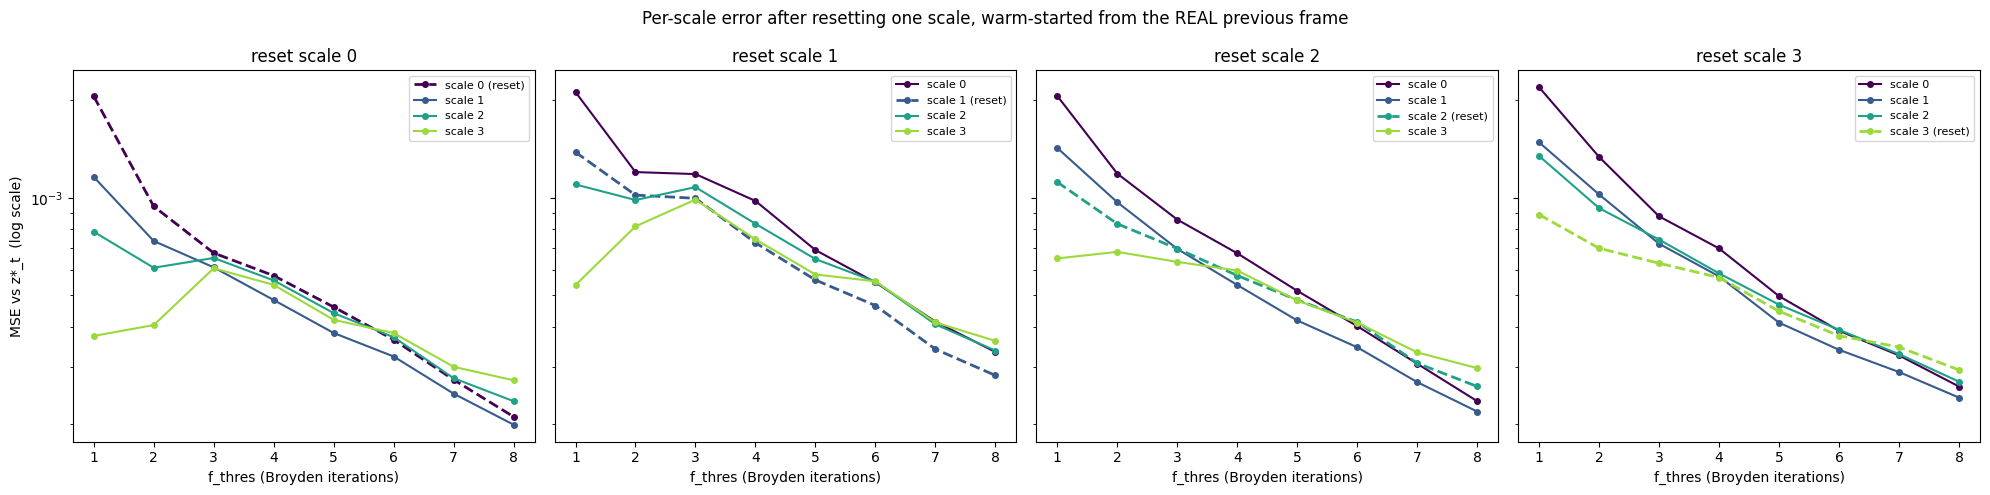

In [14]:
mse_raw_realprev = {mode: [[] for _ in range(4)] for mode in DROP_MODES}
mse_norm_realprev = {mode: [[] for _ in range(4)] for mode in DROP_MODES}

with torch.no_grad():
    for mode in DROP_MODES:
        init_state = model._build_partial_init_state(z_star_prev, mode)
        for ft in F_THRES_VALUES:
            y, _, _ = model._forward(
                [image_gpu, init_state], train_step=-1, compute_jac_loss=False, f_thres=ft,
            )
            for i in range(4):
                mse = (y[i] - z_star[i]).pow(2).mean().item()
                mse_raw_realprev[mode][i].append(mse)
                mse_norm_realprev[mode][i].append(mse / z_star_var[i])

print(f"done: {len(DROP_MODES)} configurations x {len(F_THRES_VALUES)} iteration budgets, "
      f"using the real previous frame ({PREV_FRAME_NAME})")

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for mode_idx, mode in enumerate(DROP_MODES):
    ax = axes[mode_idx]
    dropped_scale = mode_idx
    for i in range(4):
        is_dropped = (i == dropped_scale)
        ax.plot(
            F_THRES_VALUES, mse_raw_realprev[mode][i], color=colors[i],
            linestyle="--" if is_dropped else "-", lw=2 if is_dropped else 1.5,
            marker="o", ms=4, label=f"scale {i}" + (" (reset)" if is_dropped else ""),
        )
    ax.set_yscale("log")
    ax.set_xlabel("f_thres (Broyden iterations)")
    ax.set_title(f"reset scale {dropped_scale}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("MSE vs z*_t  (log scale)")
fig.suptitle("Per-scale error after resetting one scale, warm-started from the REAL previous frame")
plt.tight_layout()
plt.show()

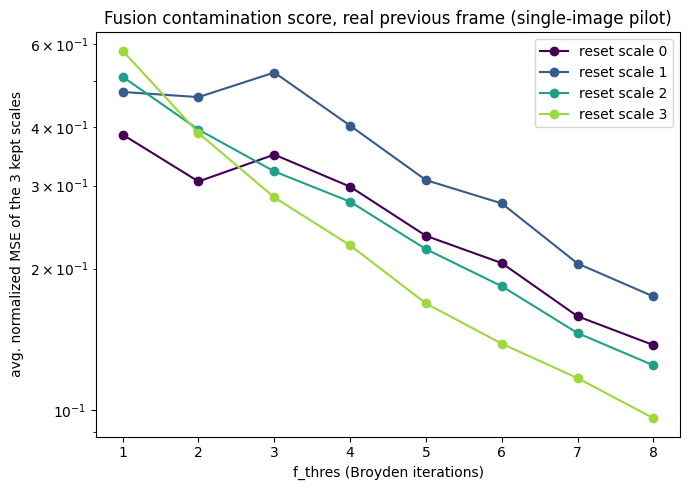

Contamination score at f_thres=4, real previous frame:
  reset scale 0: 2.9850e-01
  reset scale 1: 4.0240e-01
  reset scale 2: 2.7736e-01
  reset scale 3: 2.2404e-01

For comparison, the idealized same-image result at f_thres=4 (Section 6):
  reset scale 0: 2.2348e-01
  reset scale 1: 2.9186e-01
  reset scale 2: 1.5224e-01
  reset scale 3: 1.4460e-01


In [15]:
contamination_score_realprev = {}
for mode_idx, mode in enumerate(DROP_MODES):
    kept_scales = [i for i in range(4) if i != mode_idx]
    contamination_score_realprev[mode] = np.mean([mse_norm_realprev[mode][i] for i in kept_scales], axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
for mode_idx, mode in enumerate(DROP_MODES):
    ax.plot(F_THRES_VALUES, contamination_score_realprev[mode], color=colors[mode_idx], marker="o",
            label=f"reset scale {mode_idx}")
ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("avg. normalized MSE of the 3 kept scales")
ax.set_title("Fusion contamination score, real previous frame (single-image pilot)")
ax.legend()
plt.tight_layout()
plt.show()

REFERENCE_FT = 4
ft_idx = F_THRES_VALUES.index(REFERENCE_FT)
print(f"Contamination score at f_thres={REFERENCE_FT}, real previous frame:")
for mode_idx, mode in enumerate(DROP_MODES):
    print(f"  reset scale {mode_idx}: {contamination_score_realprev[mode][ft_idx]:.4e}")

print(f"\nFor comparison, the idealized same-image result at f_thres={REFERENCE_FT} (Section 6):")
for mode_idx, mode in enumerate(DROP_MODES):
    print(f"  reset scale {mode_idx}: {contamination_score[mode][ft_idx]:.4e}")

## 19. Conclusion (real previous frame, single-image pilot)

**The core finding survives with a genuinely real previous frame.** Contamination score at `f_thres=4`:

| | scale 0 | scale 1 | scale 2 | scale 3 |
|---|---|---|---|---|
| idealized (same image, Section 6) | 0.223 | **0.292** | 0.152 | 0.145 |
| real previous frame (Section 18) | 0.298 | **0.402** | 0.277 | 0.224 |

Resetting scale 1 is still the worst option for the other 3 scales by a clear margin, exactly as in the idealized version — this isn't an artifact of the same-image trick.

**Every score is higher with the real frame than with the idealized one**, and that's expected, not a problem: `frankfurt_000000_000293` and `frankfurt_000000_000294` are consecutive real video frames (`1/17`s apart), and the "no reset, real warm start" control in Section 17 confirms they're extremely similar but not identical — `std(z*_prev)` matches `std(z*_t)` almost exactly for every scale (e.g. scale 0: 0.0682 vs 0.0682), yet even with *no* scale reset at all, the kept scales don't start at zero error the way they did in the idealized setup (where `z*_prev` and `z*_t` were literally the same tensor). A little bit of genuine frame-to-frame drift adds a small baseline error on top of the pure fusion-contamination effect — which is exactly why Section 17's control case matters: it's the number that would need to be subtracted to isolate contamination from ordinary drift, if we wanted the "marginal" version of this score later.

**Section 17 also reproduces the known convergence-speed story with real data**: starting from the real warm start, scale 0 drops the most between `f_thres=1` and `f_thres=8` (1.84e-3 → 2.21e-4, roughly 8x), while scale 3 barely moves (3.52e-4 → 2.82e-4, about 20%) — consistent with scale 0 being the fastest scale to converge and scale 3 the slowest, the same pattern found in `convergence_population_analysis.ipynb` with a cold start.

**What this pilot does and doesn't establish:** it's one image, so it confirms the pipeline works and gives a first honest (non-idealized) data point, not population-level evidence — that would need extending Sections 16-18 to all 500 validation sequences, the same way Sections 1-7 were extended to Sections 8-11. It also isn't yet the fully paper-faithful setup: `z*_{t-1}` here is a clean 27-iteration solve, not the partially-converged state a real limited-iteration streaming chain would actually produce (Section 15's caveat). Both are natural next steps, in either order.

## 20. Extending the real-previous-frame pilot to all 500 sequences

Sections 15-19 above are one image. The same idea was re-run at population scale using two new scripts:

1. `scripts/ml_project/extract_zstar_prev_frame.py` — computes `z*_{t-1}` (baseline, `f_thres=27`, cold start) for the real frame immediately preceding each of the 500 labeled validation images, using `data/list/cityscapes/val_sequence_2_frame_seq.lst` to find each one. Cached under `z_star_cache/frame_t_minus_1/`.
2. `scripts/ml_project/extract_fusion_contamination_realprev.py` — for each image and **5** configurations (`no_reset`, the full real warm start with nothing zeroed, plus the 4 `drop_scaleK_previous` modes), builds the initial state from `z*_{t-1}` and re-solves at `f_thres=1..8`, recording per-channel MSE against the current frame's own `z*_t`. Saved to `results/ml_project/fusion_contamination_realprev_all_images.pt`.

`no_reset` is the population equivalent of Section 17's control; the 4 `drop_scaleK_previous` modes are the population equivalent of Section 18. Both scripts were smoke-tested on 3 images first (which reproduced Section 18's exact numbers for `frankfurt_000000_000294`, confirming correctness) before running on all 500. Sections 21-24 below only read the two files these scripts already wrote and do not need the model or the GPU.

## 21. Loading the real-previous-frame results for all 500 images

`MODES` here has 5 entries (`no_reset` first, then the 4 `drop_scaleK_previous` modes) — one more than `DROP_MODES` used in Sections 8-14, which never included a no-reset control. We also confirm the image order matches `fusion_image_names` from Section 8, so `z_star_var_per_image` (already computed in Section 9) can be reused directly instead of recomputing it.

In [16]:
REALPREV_RESULTS_PATH = Path("results/ml_project/fusion_contamination_realprev_all_images.pt")

realprev_results = torch.load(REALPREV_RESULTS_PATH, map_location="cpu", weights_only=False)
realprev_image_names = realprev_results["image_names"]
realprev_mse_stack = torch.stack(realprev_results["mse"])  # (num_images, 5 modes, 8 f_thres, 1320 channels)

MODES = ["no_reset"] + DROP_MODES

assert realprev_image_names == fusion_image_names, \
    "image order differs from Section 8 -- cannot reuse z_star_var_per_image directly"

print(f"{len(realprev_image_names)} images loaded from {REALPREV_RESULTS_PATH.name}")
print("shape (images, modes, f_thres, channels):", tuple(realprev_mse_stack.shape))
print("modes:", MODES)
print("image order matches Section 8's fusion_image_names: confirmed")

500 images loaded from fusion_contamination_realprev_all_images.pt
shape (images, modes, f_thres, channels): (500, 5, 8, 1320)
modes: ['no_reset', 'drop_scale0_previous', 'drop_scale1_previous', 'drop_scale2_previous', 'drop_scale3_previous']
image order matches Section 8's fusion_image_names: confirmed


## 22. Population convergence with a real warm start (no scale reset)

Population equivalent of Section 17: for each scale, the median (and 10th-90th percentile band) across all 500 images of the mean per-channel MSE against `z*_t`, using the `no_reset` mode (`realprev_mse_stack[:, 0, ...]`) -- the full real warm start with nothing zeroed out.

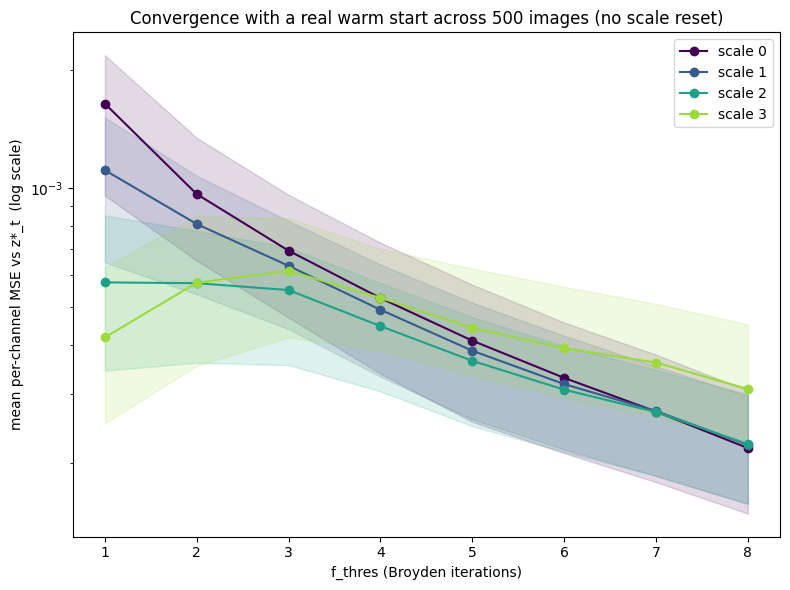

Real warm-start (no reset), median MSE across all images:
  scale 0: f_thres=1 -> 1.6450e-03   f_thres=8 -> 2.1775e-04   (reduced 86.8%)
  scale 1: f_thres=1 -> 1.1131e-03   f_thres=8 -> 2.2180e-04   (reduced 80.1%)
  scale 2: f_thres=1 -> 5.7598e-04   f_thres=8 -> 2.2283e-04   (reduced 61.3%)
  scale 3: f_thres=1 -> 4.1705e-04   f_thres=8 -> 3.0797e-04   (reduced 26.2%)


In [17]:
NO_RESET_MODE_IDX = MODES.index("no_reset")

fig, ax = plt.subplots(figsize=(8, 6))
scale_avg_mse_per_image = np.zeros((len(realprev_image_names), 4, len(F_THRES_VALUES)))
for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    scale_avg_mse_per_image[:, i, :] = realprev_mse_stack[:, NO_RESET_MODE_IDX, :, sl].mean(dim=2).numpy()

    data = scale_avg_mse_per_image[:, i, :]  # (images, f_thres)
    median = np.median(data, axis=0)
    p10, p90 = np.percentile(data, [10, 90], axis=0)
    ax.plot(F_THRES_VALUES, median, color=colors[i], marker="o", label=f"scale {i}")
    ax.fill_between(F_THRES_VALUES, p10, p90, color=colors[i], alpha=0.15)

ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("mean per-channel MSE vs z*_t  (log scale)")
ax.set_title(f"Convergence with a real warm start across {len(realprev_image_names)} images (no scale reset)")
ax.legend()
plt.tight_layout()
plt.show()

print("Real warm-start (no reset), median MSE across all images:")
for i in range(4):
    med_f1 = np.median(scale_avg_mse_per_image[:, i, 0])
    med_f8 = np.median(scale_avg_mse_per_image[:, i, -1])
    print(f"  scale {i}: f_thres=1 -> {med_f1:.4e}   f_thres=8 -> {med_f8:.4e}   "
          f"(reduced {100 * (1 - med_f8 / med_f1):.1f}%)")

## 23. Contamination score across all 500 images, real previous frame

Population equivalent of Section 18/10, computed identically to Section 9's `contamination_per_image` (average, over the 3 kept scales, of each scale's MSE normalized by that image's own `z_star_var_per_image`), but reading from `realprev_mse_stack`'s 4 `drop_scaleK_previous` modes (indices 1-4, since index 0 is `no_reset`) instead of the idealized `fusion_mse_stack`.

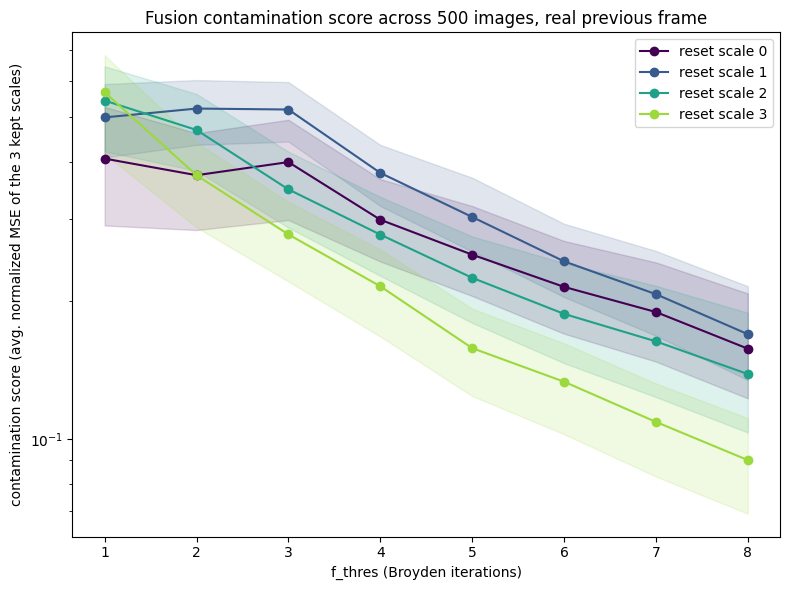

Contamination score at f_thres=4, real previous frame, across all 500 images:
  reset scale 0: median=2.9946e-01  mean=3.0255e-01
  reset scale 1: median=3.7840e-01  mean=3.7789e-01
  reset scale 2: median=2.7801e-01  mean=2.8024e-01
  reset scale 3: median=2.1473e-01  mean=2.1445e-01

For comparison, the idealized same-image population result at f_thres=4 (Section 10):
  reset scale 0: median=2.2407e-01  mean=2.2749e-01
  reset scale 1: median=2.7618e-01  mean=2.8151e-01
  reset scale 2: median=1.7090e-01  mean=1.7626e-01
  reset scale 3: median=1.2235e-01  mean=1.2508e-01


In [18]:
contamination_per_image_realprev = np.zeros((len(realprev_image_names), len(DROP_MODES), len(F_THRES_VALUES)))
for mode_idx in range(len(DROP_MODES)):
    stack_mode_idx = MODES.index(DROP_MODES[mode_idx])  # +1 offset vs. mode_idx, since MODES[0] is "no_reset"
    kept_scales = [i for i in range(4) if i != mode_idx]
    for i in kept_scales:
        sl = slice(boundaries[i], boundaries[i + 1])
        scale_mse = realprev_mse_stack[:, stack_mode_idx, :, sl].mean(dim=2).numpy()  # (images, f_thres)
        contamination_per_image_realprev[:, mode_idx, :] += scale_mse / z_star_var_per_image[:, i:i + 1]
contamination_per_image_realprev /= 3

fig, ax = plt.subplots(figsize=(8, 6))
for mode_idx in range(len(DROP_MODES)):
    data = contamination_per_image_realprev[:, mode_idx, :]  # (images, f_thres)
    median = np.median(data, axis=0)
    p10, p90 = np.percentile(data, [10, 90], axis=0)
    ax.plot(F_THRES_VALUES, median, color=colors[mode_idx], marker="o", label=f"reset scale {mode_idx}")
    ax.fill_between(F_THRES_VALUES, p10, p90, color=colors[mode_idx], alpha=0.15)

ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("contamination score (avg. normalized MSE of the 3 kept scales)")
ax.set_title(f"Fusion contamination score across {len(realprev_image_names)} images, real previous frame")
ax.legend()
plt.tight_layout()
plt.show()

REFERENCE_FT = 4
ft_idx = F_THRES_VALUES.index(REFERENCE_FT)
print(f"Contamination score at f_thres={REFERENCE_FT}, real previous frame, across all {len(realprev_image_names)} images:")
for mode_idx in range(len(DROP_MODES)):
    vals = contamination_per_image_realprev[:, mode_idx, ft_idx]
    print(f"  reset scale {mode_idx}: median={np.median(vals):.4e}  mean={vals.mean():.4e}")

print(f"\nFor comparison, the idealized same-image population result at f_thres={REFERENCE_FT} (Section 10):")
for mode_idx in range(len(DROP_MODES)):
    vals = contamination_per_image[:, mode_idx, ft_idx]
    print(f"  reset scale {mode_idx}: median={np.median(vals):.4e}  mean={vals.mean():.4e}")

## 24. Overall conclusion (real previous frame, all 500 sequences)

**The single-image pilot was representative, not a fluke.** Contamination score at `f_thres=4`, median across 500 images:

| | scale 0 | scale 1 | scale 2 | scale 3 |
|---|---|---|---|---|
| idealized, single image (Section 6) | 0.223 | **0.292** | 0.152 | 0.145 |
| idealized, 500 images (Section 10) | 0.224 | **0.276** | 0.171 | 0.122 |
| real previous frame, single image (Section 18) | 0.298 | **0.402** | 0.277 | 0.224 |
| real previous frame, 500 images (Section 23) | 0.299 | **0.378** | 0.278 | 0.215 |

Four independent measurements, same ranking every time: **reset scale 1 > reset scale 0 > reset scale 2 > reset scale 3**. The real-previous-frame population result (0.299 / 0.378 / 0.278 / 0.215) sits almost on top of the single-image pilot (0.298 / 0.402 / 0.277 / 0.224) — confirming that `frankfurt_000000_000293→294` wasn't a lucky or unusual pair, and that resetting scale 1 through fusion is measurably worse than resetting any other scale, across the whole validation set, with genuinely different previous-frame content in every one of the 500 cases.

As with the single-image pilot, every real-frame score is higher than its idealized counterpart (0.299 vs 0.224 for scale 0, 0.378 vs 0.276 for scale 1, etc.) — real consecutive frames carry a small amount of genuine content drift that the idealized same-image setup couldn't have, adding a baseline error on top of the pure fusion-contamination effect.

**Section 22 confirms the convergence-speed story holds population-wide with a real warm start, too.** Median reduction in MSE from `f_thres=1` to `f_thres=8`: scale 0 **86.8%**, scale 1 80.1%, scale 2 61.3%, scale 3 only **26.2%** — the same fast-scale-0/slow-scale-3 ordering seen in every convergence measurement in this project (`convergence_population_analysis.ipynb`'s cold-start version, and Section 17's single-image real warm start), now confirmed with a real warm start across all 500 sequences.

**What this does and doesn't establish:** this is now solid population-level evidence, with genuinely different real video content in every case, that scale 1's importance for warm-starting comes from how much its absence disturbs the other 3 scales through fusion — not from being the slowest scale to converge on its own (it isn't; scale 3 is, consistently, across cold-start and warm-start, idealized and real). What remains open, as noted in Section 15, is the fully paper-faithful setup: `z*_{t-1}` here is still a clean 27-iteration solve for a single previous frame, not the partially-converged state a real multi-frame streaming chain with a small iteration budget would actually produce.

## 25. Does contamination eventually vanish? Extending to `f_thres=1..27` (single image)

Every experiment so far stops at `f_thres=8`, matching the iteration budgets the real streaming sweep actually uses. That's the right choice for the notebook's main question (does resetting a scale hurt *within the budgets StreamDEQ actually runs with*), but it leaves open a narrower, more theoretical question: if the solver were allowed to keep going well past any realistic streaming budget, does the contamination from resetting a scale eventually disappear, or does it linger?

We already have strong reason to expect it disappears: `equilibrium_convergence.ipynb` showed that, from a cold start, every scale becomes bit-identical to `z*` by `f_thres=26` (Broyden's own early-stopping fires for every scale at once, since all 4 are solved as one concatenated vector). Since `z*` is a genuine fixed point, reaching it from *any* reasonable starting state should be possible given enough iterations -- a reset scale is just a different (worse) starting point, not a different destination.

This section checks that directly rather than assuming it, but keeps the cost low: **one image** (the same `frankfurt_000000_000294` / real previous frame `293` pair used throughout Sections 15-24), all **5** configurations (`no_reset` plus the 4 `drop_scaleK_previous` modes), `f_thres = 1` to `27` (`config.DEQ.F_THRES`) instead of `1` to `8`. That's `5 × 27 = 135` forward passes for a single image -- cheap enough to run directly in this notebook, unlike redoing this range for all 500 images with every configuration, which is why we're not doing that (see the discussion that led here).

done: 5 configurations x 27 iteration budgets = 135 forward passes, single image


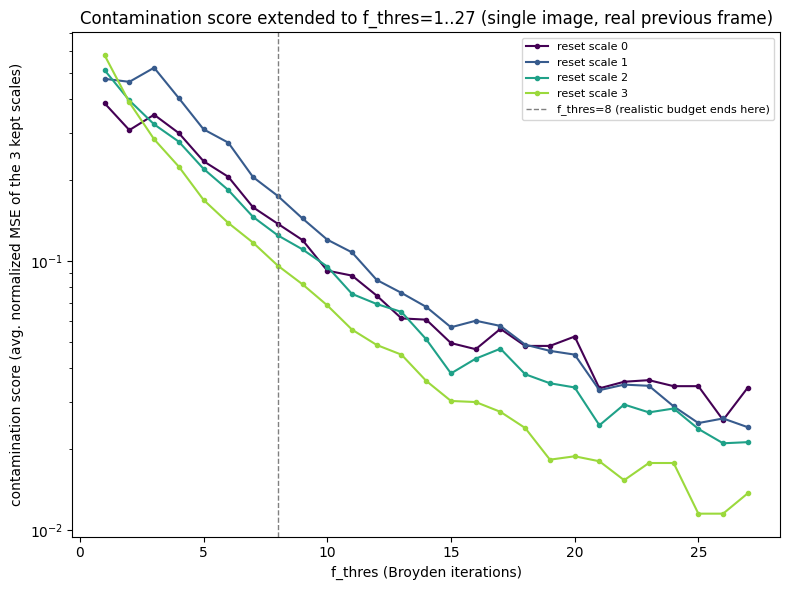

Contamination score at a few reference points:
  f_thres=4:  scale0=2.98e-01  scale1=4.02e-01  scale2=2.77e-01  scale3=2.24e-01
  f_thres=8:  scale0=1.38e-01  scale1=1.74e-01  scale2=1.25e-01  scale3=9.62e-02
  f_thres=16:  scale0=4.71e-02  scale1=6.00e-02  scale2=4.34e-02  scale3=3.00e-02
  f_thres=27:  scale0=3.39e-02  scale1=2.42e-02  scale2=2.13e-02  scale3=1.37e-02


In [19]:
F_THRES_VALUES_EXT = list(range(1, config.DEQ.F_THRES + 1))  # 1..27

# mse_ext[mode][scale] -> list over F_THRES_VALUES_EXT of that scale's per-channel MSE tensor
mse_ext = {mode: [[] for _ in range(4)] for mode in MODES}

with torch.no_grad():
    for mode in MODES:
        init_state = z_star_prev if mode == "no_reset" else model._build_partial_init_state(z_star_prev, mode)
        for ft in F_THRES_VALUES_EXT:
            y, _, _ = model._forward(
                [image_gpu, init_state], train_step=-1, compute_jac_loss=False, f_thres=ft,
            )
            for i in range(4):
                per_channel_mse = (y[i] - z_star[i]).pow(2).mean(dim=(0, 2, 3)).cpu()
                mse_ext[mode][i].append(per_channel_mse)

mse_ext = {mode: [torch.stack(scale_list) for scale_list in mse_ext[mode]] for mode in MODES}  # (27, C_i) per scale

print(f"done: {len(MODES)} configurations x {len(F_THRES_VALUES_EXT)} iteration budgets = "
      f"{len(MODES) * len(F_THRES_VALUES_EXT)} forward passes, single image")

# Contamination score extended to f_thres=1..27, same definition as Sections 6/18 (average, over the
# 3 kept scales, of MSE normalized by z_star_var -- no_reset has no "kept" scales to single out, so
# it's excluded from this particular score, though its raw per-scale curves are plotted below too.
# mse_ext[mode][i] is (27, C_i) -- average over channels (dim=1) first so every kept scale contributes
# a plain (27,) vector before combining across scales (their channel counts differ: 88/176/352/704).
contamination_score_ext = {}
for mode_idx, mode in enumerate(DROP_MODES):
    kept_scales = [i for i in range(4) if i != mode_idx]
    contamination_score_ext[mode] = np.mean(
        [(mse_ext[mode][i].mean(dim=1) / z_star_var[i]).numpy() for i in kept_scales], axis=0
    )  # (len(F_THRES_VALUES_EXT),)

fig, ax = plt.subplots(figsize=(8, 6))
for mode_idx, mode in enumerate(DROP_MODES):
    ax.plot(F_THRES_VALUES_EXT, contamination_score_ext[mode], color=colors[mode_idx], marker="o", ms=3,
            label=f"reset scale {mode_idx}")
ax.axvline(8, color="gray", lw=1, ls="--", label="f_thres=8 (realistic budget ends here)")
ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("contamination score (avg. normalized MSE of the 3 kept scales)")
ax.set_title("Contamination score extended to f_thres=1..27 (single image, real previous frame)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Contamination score at a few reference points:")
for ft in [4, 8, 16, 27]:
    ft_idx = F_THRES_VALUES_EXT.index(ft)
    print(f"  f_thres={ft}:  " + "  ".join(
        f"scale{mode_idx}={contamination_score_ext[mode][ft_idx]:.2e}" for mode_idx, mode in enumerate(DROP_MODES)
    ))

## 26. Conclusion (extended range)

**Contamination does fade with enough iterations, as expected.** Every configuration's score drops roughly 10-15x from `f_thres=4` to `f_thres=27` (e.g. reset scale 1: 0.402 -> 0.024), confirming this is a short-budget effect, not a permanent divergence -- consistent with `z*` being a genuine fixed point reachable from any reasonable starting condition, given enough solver iterations.

**Within the realistic streaming budget, the known ranking holds exactly.** At `f_thres=4` and `f_thres=8`, reset scale 1 remains clearly the worst (0.402 and 0.174), matching every other measurement in this notebook.

**An honest nuance shows up past the realistic budget, though.** By `f_thres=16` scale 1 is still worst (0.060), but by `f_thres=27` the ranking flips: reset **scale 0** becomes the highest (0.034), while scale 1's score has fallen faster into second place (0.024) -- scale 1's contamination decays quicker in the tail than scale 0's does. This doesn't change the practical conclusion (every realistic streaming config uses `f_thres<=8`, where scale 1 is unambiguously worst), but it's worth reporting rather than glossing over: whatever makes scale 0 special for its own fast recovery (Section 12: it recovers 65.6% of its own error in a single iteration, the fastest of the four) doesn't necessarily make the *disturbance it causes others* fade at the same rate. This late-budget crossover is a loose thread, not something this notebook resolves -- flagging it for anyone who explores the `f_thres>8` regime further.

## 27. Per-channel convergence rate for `no_reset`, all 500 images

Same style as `convergence_population_analysis.ipynb`'s Section 9 (`plot_all_channels_overlaid`): every channel of a scale overlaid in one plot, each normalized by its own `f_thres=1` value (so all curves start at 1.0 and only their *shape* differs), colored by that channel's own convergence rate (a straight-line fit of `log10(MSE)` vs. `f_thres`) -- slowest channels dark, fastest yellow.

**This uses the population data already loaded in Section 21** (`realprev_mse_stack`, `no_reset` mode, averaged over all 500 images) -- the real equilibrium `z*_{t-1}` of each image's own real preceding frame, warm-started into frame `t`, exactly as extracted by `extract_fusion_contamination_realprev.py`. The only difference from `convergence_population_analysis.ipynb`'s version: that one used a **cold start** (`z^0=0`) over `f_thres=1..27`; this one uses the **real warm start** over `f_thres=1..8` (the full range that script extracted, matching the realistic streaming budgets) -- so the rate fit below uses the whole `1..8` window instead of `1..10`, since that's all the data available here.

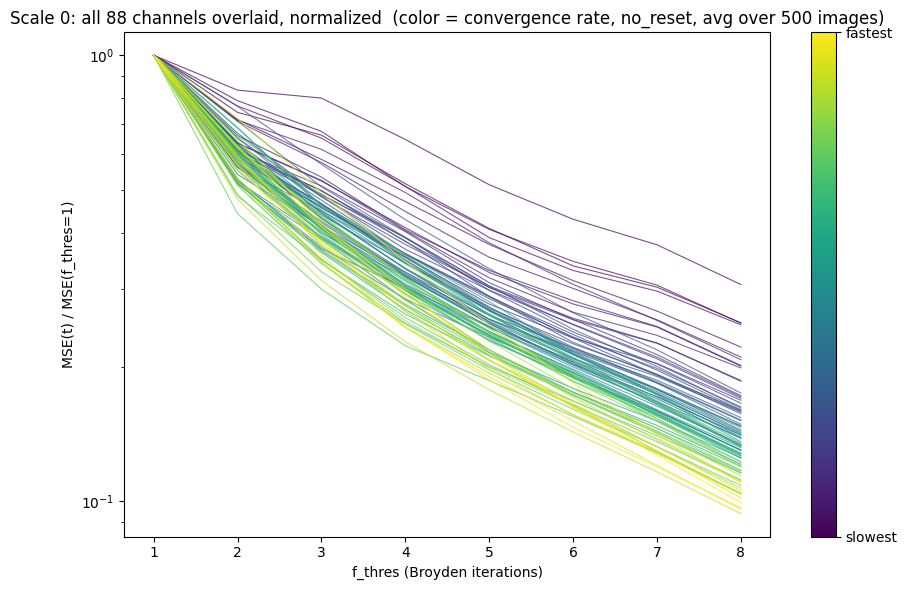

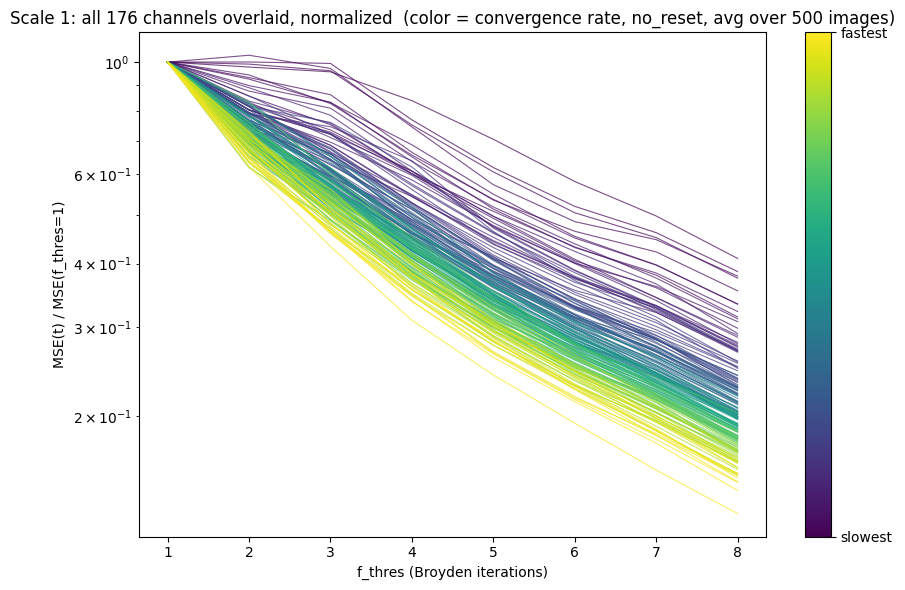

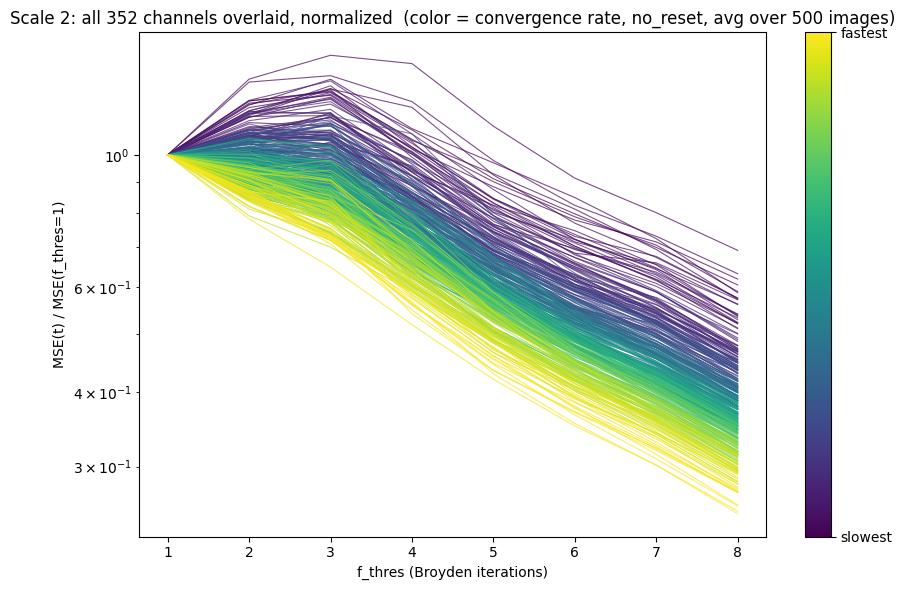

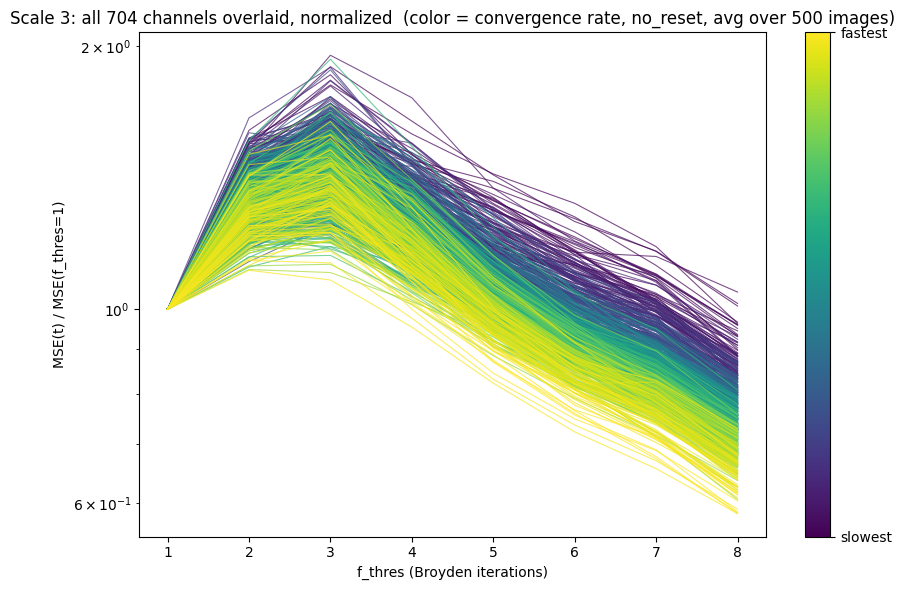

scale 0: median decay rate = 0.117 log10-units/iteration
scale 1: median decay rate = 0.099 log10-units/iteration
scale 2: median decay rate = 0.066 log10-units/iteration
scale 3: median decay rate = 0.030 log10-units/iteration


In [20]:
channel_avg_no_reset_pop = realprev_mse_stack[:, NO_RESET_MODE_IDX, :, :].mean(dim=0).numpy()  # (8, 1320), avg over 500 images
relative_mse_no_reset_pop = channel_avg_no_reset_pop / channel_avg_no_reset_pop[0:1, :]  # normalized by f_thres=1

FIT_START, FIT_END = 1, 8  # the entire available range for this real-warm-start extraction (only goes to 8)
fit_indices = [F_THRES_VALUES.index(ft) for ft in range(FIT_START, FIT_END + 1)]
x_fit = np.array(F_THRES_VALUES)[fit_indices]

decay_rate_no_reset_pop = np.zeros(channel_avg_no_reset_pop.shape[1])
for c in range(channel_avg_no_reset_pop.shape[1]):
    y_fit = np.log10(channel_avg_no_reset_pop[fit_indices, c])
    slope, _intercept = np.polyfit(x_fit, y_fit, 1)
    decay_rate_no_reset_pop[c] = -slope  # flip sign: higher = faster


def plot_channels_by_rate_pop(scale_i):
    start, end = boundaries[scale_i], boundaries[scale_i + 1]
    n_channels = end - start
    cmap = plt.cm.viridis
    order = np.argsort(decay_rate_no_reset_pop[start:end])

    fig, ax = plt.subplots(figsize=(9, 6))
    for rank, local_idx in enumerate(order):
        global_idx = start + local_idx
        color = cmap(rank / max(n_channels - 1, 1))
        ax.plot(F_THRES_VALUES, relative_mse_no_reset_pop[:, global_idx], color=color, lw=0.8, alpha=0.7)

    ax.set_yscale("log")
    ax.set_xlabel("f_thres (Broyden iterations)")
    ax.set_ylabel("MSE(t) / MSE(f_thres=1)")
    ax.set_title(f"Scale {scale_i}: all {n_channels} channels overlaid, normalized  "
                 f"(color = convergence rate, no_reset, avg over 500 images)")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(["slowest", "fastest"])
    plt.tight_layout()
    plt.show()


for i in range(4):
    plot_channels_by_rate_pop(i)

for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    print(f"scale {i}: median decay rate = {np.median(decay_rate_no_reset_pop[sl]):.3f} log10-units/iteration")

## 28. Conclusion (per-channel convergence rate, `no_reset`, all 500 images)

Median per-channel decay rate (log10-units of MSE reduction per iteration), real warm start, averaged over all 500 images: **scale 0 = 0.117** (fastest), scale 1 = 0.099, scale 2 = 0.066, **scale 3 = 0.030** (slowest).

Same ordering as everywhere else in this project -- scale 0 fastest, scale 3 slowest -- now confirmed with the real warm start, at population scale, not just a single image or a cold start. Scale 0's rate (0.117) lines up almost exactly with `convergence_population_analysis.ipynb`'s cold-start rate for the same scale (0.118) -- for the fastest scale, warm-starting from a real previous frame barely changes its relative convergence speed. Scales 2 and 3 diverge more from their cold-start rates (0.066 vs. 0.107, and 0.030 vs. 0.075) -- part of that gap is a real effect of warm-starting from a state already close to the answer, and part of it is a weaker fit: this rate is estimated over `f_thres=1..8` here (all that this extraction has), versus `1..10` in the cold-start version, so it's a noisier estimate over a shorter window. Either way, the *order* -- which is the finding this notebook actually depends on -- is unaffected by any of that and holds up cleanly at population scale.